This notebook conducts quantitative analysis of the price movement of stocks based on technical indicators like moving averages, RSI, and MACD. The aim is to detecting the  trends and momentem changes and possible overbought or oversold situations.

Note: 'ta' library is used as a compatible alternative to TA-Lib,
providing the same technical indicators with a simpler Windows installation.TA-Lib requires manual C++ binary installation on Windows.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator

import warnings
warnings.filterwarnings("ignore")

In [36]:
df = pd.read_csv("../data/raw/AAPL.csv")

In [37]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [38]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB


In [39]:
print(df.isnull().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [40]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.isnull().sum()
df = df.dropna()

In [41]:
numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

In [42]:
sma_20 = SMAIndicator(close=df["Close"], window=20)

df["SMA_20"] = sma_20.sma_indicator()

In [43]:
sma_50 = SMAIndicator(close=df["Close"], window=50)

df["SMA_50"] = sma_50.sma_indicator()

In [44]:
ema_20 = EMAIndicator(close=df["Close"], window=20)

df["EMA_20"] = ema_20.ema_indicator()

SMA and EMA smooth short-term fluctuations to reveal the broader trend. 
Crossovers between SMA_20 and SMA_50 can signal potential bullish or bearish reversals.

In [45]:
rsi = RSIIndicator(close=df["Close"], window=14)

df["RSI"] = rsi.rsi()

Initial RSI values contain null entries because the indicator requires sufficient historical observations before calculations can be performed.

RSI values above 70 indicate overbought conditions; below 30 suggests oversold. 
These zones highlight potential reversal points in AAPL's price action.

In [46]:
macd = MACD(close=df["Close"])

df["MACD"] = macd.macd()
df["MACD_signal"] = macd.macd_signal()

MACD crossovers with the signal line reveal momentum shifts. 
When MACD crosses above the signal line, it suggests building bullish momentum.

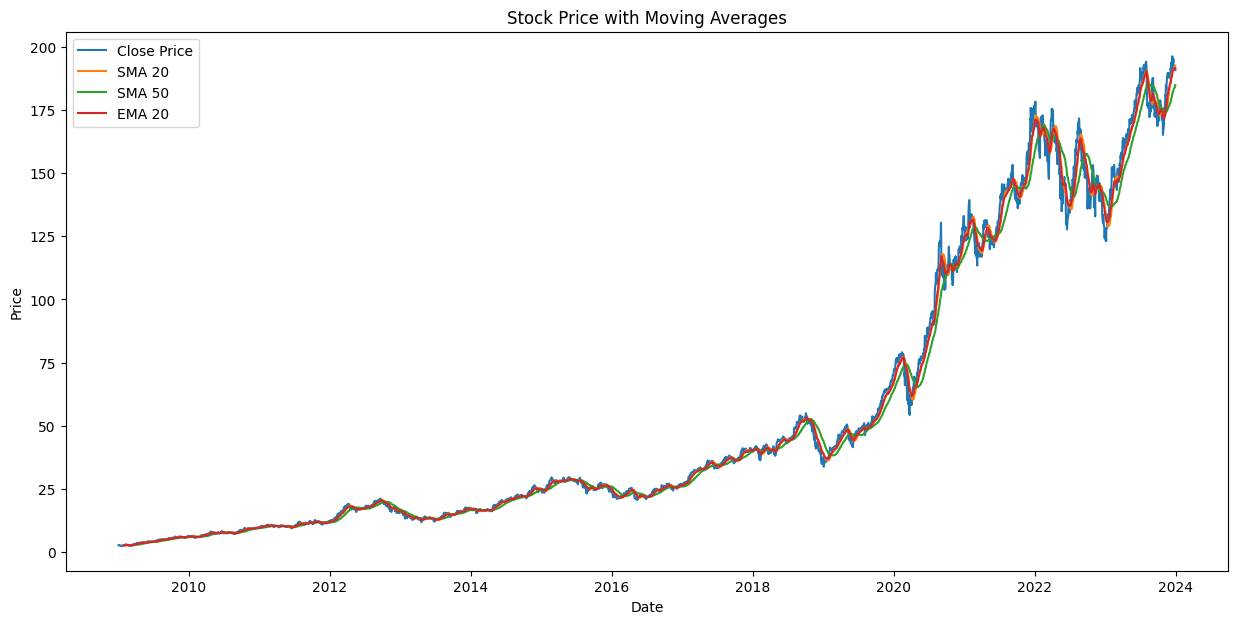

In [47]:
plt.figure(figsize=(15,7))

plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["SMA_50"], label="SMA 50")
plt.plot(df["Date"], df["EMA_20"], label="EMA 20")

plt.title("Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

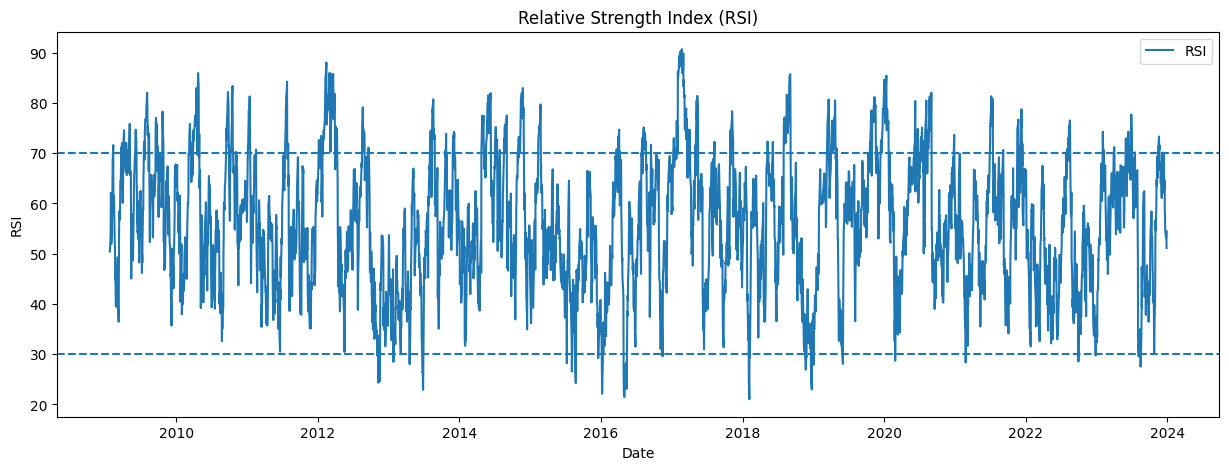

In [48]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["RSI"], label="RSI")

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()
plt.show()

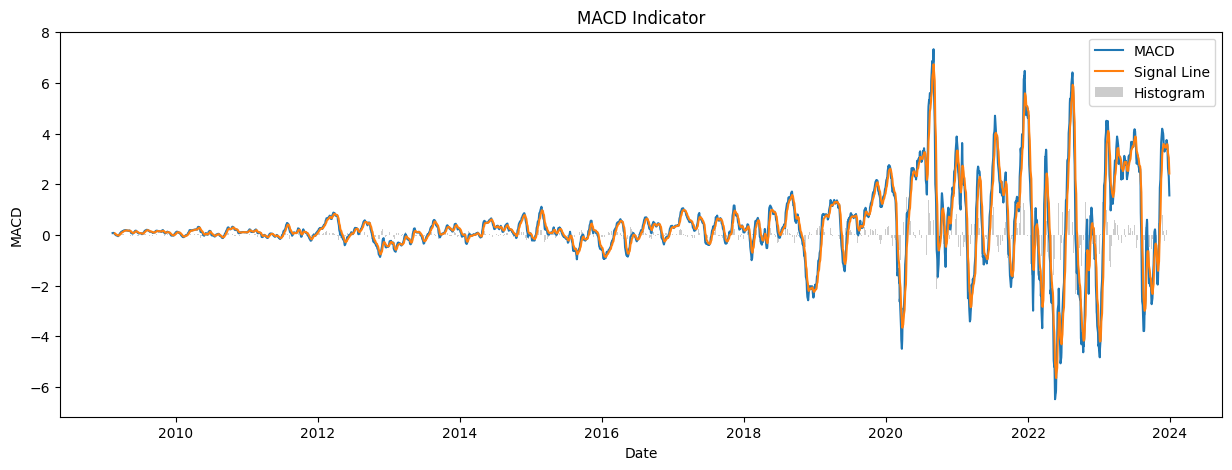

In [49]:
df["MACD_hist"] = macd.macd_diff()

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df["Date"], df["MACD"], label="MACD")
ax.plot(df["Date"], df["MACD_signal"], label="Signal Line")
ax.bar(df["Date"], df["MACD_hist"], label="Histogram", color="grey", alpha=0.4)

ax.set_title("MACD Indicator")
ax.set_xlabel("Date")
ax.set_ylabel("MACD")
ax.legend()

plt.show()

In [50]:
df["Daily_Return"] = df["Close"].pct_change()

In [51]:
volatility = df["Daily_Return"].std()

print("Daily Volatility:", volatility)

Daily Volatility: 0.018010113628161184


In [52]:
df["Cumulative_Return"] = (1 + df["Daily_Return"]).cumprod()

In [53]:
# Financial Metrics (computed manually due to PyNance API limitations)

# Annualized volatility (std of daily returns * sqrt of 252 trading days)
ann_volatility = df["Daily_Return"].std() * np.sqrt(252)
print("Annualized Volatility:", round(ann_volatility, 4))

# Sharpe Ratio (assuming 0 risk-free rate)
sharpe_ratio = df["Daily_Return"].mean() / df["Daily_Return"].std() * np.sqrt(252)
print("Sharpe Ratio:", round(sharpe_ratio, 4))

# Total cumulative return
total_return = df["Cumulative_Return"].iloc[-1] - 1
print("Total Return over period:", round(total_return * 100, 2), "%")

# Max drawdown
rolling_max = df["Close"].cummax()
drawdown = (df["Close"] - rolling_max) / rolling_max
print("Max Drawdown:", round(drawdown.min() * 100, 2), "%")

Annualized Volatility: 0.2859
Sharpe Ratio: 1.1362
Total Return over period: 6907.74 %
Max Drawdown: -43.8 %


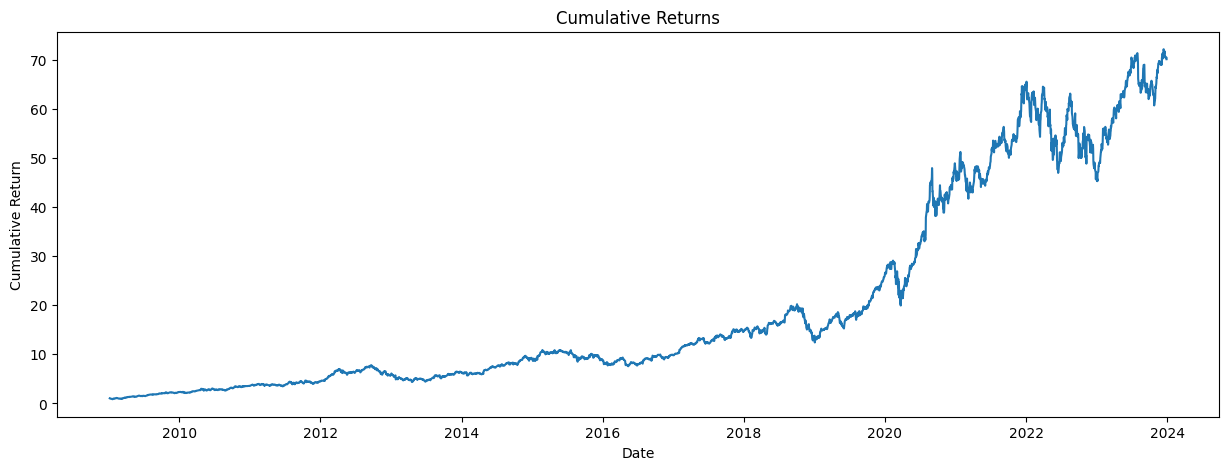

In [54]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["Cumulative_Return"])

plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.show()

## Data Quality and Preparation

The dataset required preprocessing steps including date conversion, missing value handling, and numeric type validation. Initial rows containing insufficient rolling-window history for technical indicators produced null values and were handled appropriately.

## Conclusion

Technical indicators reveal meaningful patterns in price momentum, trend direction, and market conditions. Moving averages provided trend visibility, RSI highlighted overbought and oversold regions, and MACD identified momentum shifts.


These indicators collectively provide a foundation for quantitative trading analysis and can later be integrated with sentiment analysis from financial news data.